In [1]:
import os
import json
import numpy as np
import re
from tqdm import tqdm
import nltk
nltk.download('punkt')

import matplotlib.pyplot as plt
from PIL import Image

from collections import defaultdict
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Concatenate, Dropout, Concatenate, Dot, RepeatVector,Add, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("google.colab not found. Assuming not running in Colab or Drive is already mounted.")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

Mounted at /content/drive
Google Drive mounted successfully.


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step


  2%|▏         | 1/50 [00:01<01:07,  1.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step


  4%|▍         | 2/50 [00:01<00:43,  1.10it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step


 98%|█████████▊| 49/50 [00:37<00:00,  1.54it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step


100%|██████████| 50/50 [00:37<00:00,  1.32it/s]


Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 738ms/step - loss: 9.9371
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 739ms/step - loss: 4.7255
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 33s 722ms/step - loss: 3.6169
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 35s 754ms/step - loss: 3.0282
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 784ms/step - loss: 2.7044
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 717ms/step - loss: 2.4159
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 726ms/step - loss: 2.2244
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 731ms/step - loss: 1.9682
Epoch 9/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 40s 719ms/step - loss: 1.8964
Epoch 10/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 732ms/step - loss: 1.7559
Epoch 11/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 770ms/step - loss: 1.6340
Epoch 12/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 725ms/step - loss: 1.5511
Epoch 13/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 35s 754ms/step - loss: 1.4745
Epoch 14/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 757ms/step - loss: 1.3659
Epoch 15/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 33s 

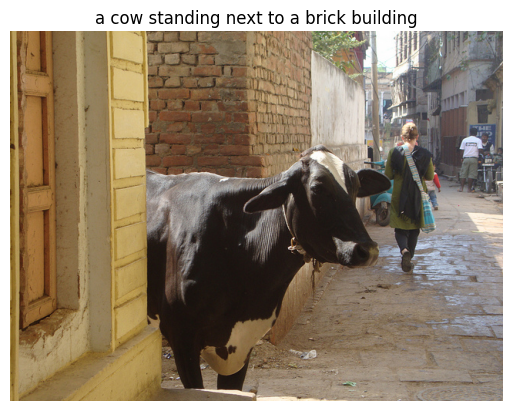

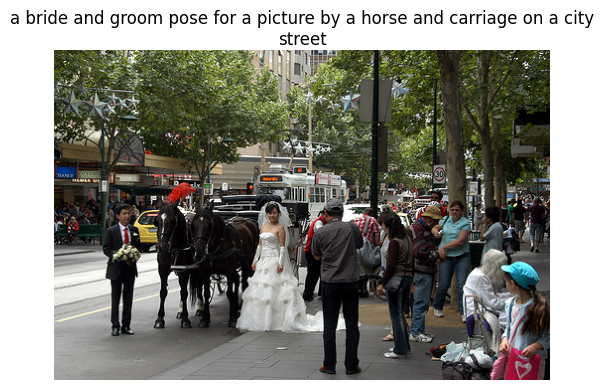

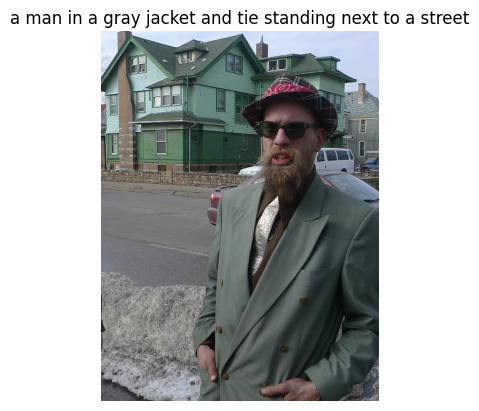

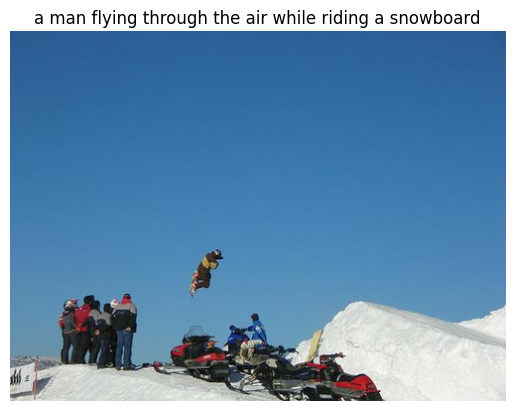

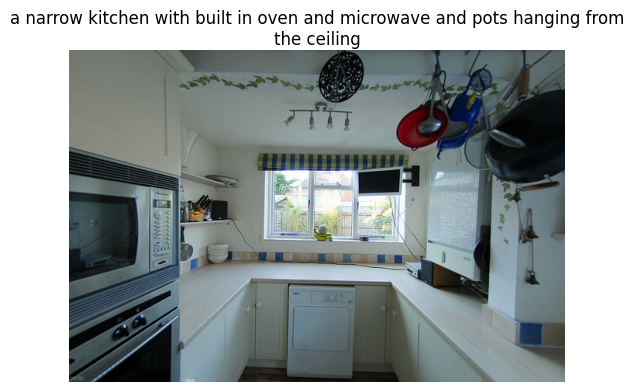

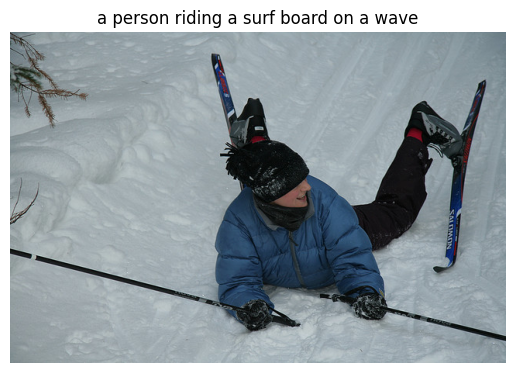

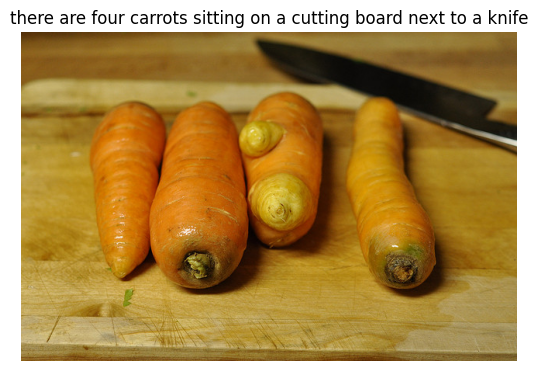

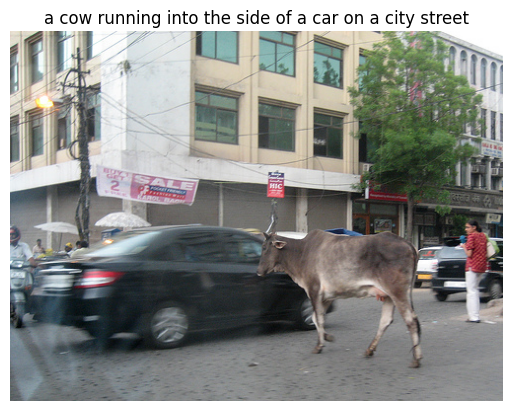

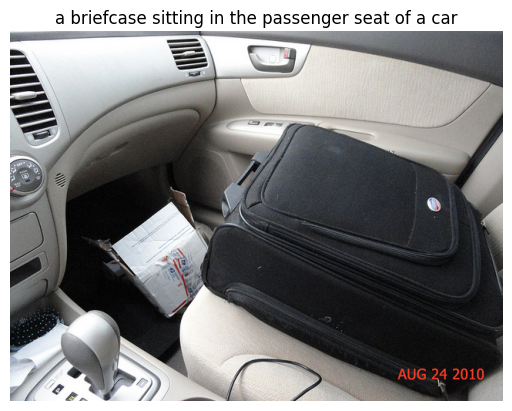

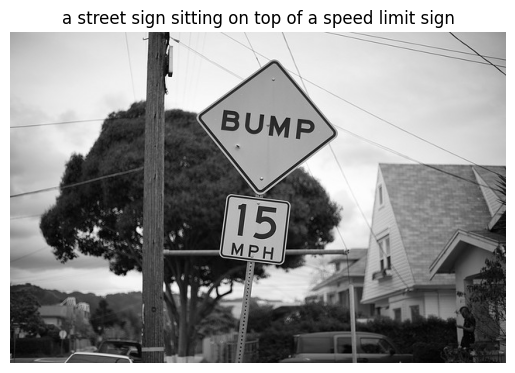

BLEU-1: 0.8234
BLEU-2: 0.7819
BLEU-3: 0.7569
BLEU-4: 0.7434


In [13]:


# ---- PATHS ----
IMAGE_DIR = '/content/drive/MyDrive/train2014'
CAPTION_FILE = '/content/drive/MyDrive/annotations/captions_train2014.json'


# ---- 1. LOAD CAPTIONS ----
with open(CAPTION_FILE) as f:
    data = json.load(f)

captions_dict = defaultdict(list)
for annot in data['annotations']:
    img_id = annot['image_id']
    caption = annot['caption']
    captions_dict[img_id].append(caption)

# ---- 2. CLEAN TEXT ----
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # removes punctuation, not letters
    text = re.sub(r'\s+', ' ', text)     # remove extra spaces
    return 'startseq ' + text.strip() + ' endseq'

for img_id in captions_dict:
    captions_dict[img_id] = [clean_text(cap) for cap in captions_dict[img_id]]

# ---- 3. LOAD IMAGES & EXTRACT FEATURES ----
vgg_model = VGG16(include_top=False, weights='imagenet')
vgg_model = Model(inputs=vgg_model.input, outputs=vgg_model.output)

def extract_features(filename):
    img = load_img(filename, target_size=(224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    features = vgg_model.predict(img)
    return features.reshape(-1)

# Limit to 50 images for quick test
image_files = os.listdir(IMAGE_DIR)[:50]
features_dict = {}
image_ids = []

for img_file in tqdm(image_files):
    img_id = int(img_file.split('_')[-1].split('.')[0])
    if img_id in captions_dict:
        path = os.path.join(IMAGE_DIR, img_file)
        features_dict[img_id] = extract_features(path)
        image_ids.append(img_id)

# ---- 4. TOKENIZER ----
all_captions = []
for caps in captions_dict.values():
    all_captions.extend(caps)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in all_captions)

# ---- 5. CREATE SEQUENCES ----
def create_sequences(tokenizer, max_length, desc_list, photo_feature, vocab_size):
    X1, X2, y = [], [], []
    for desc in desc_list:
        seq = tokenizer.texts_to_sequences([desc])[0]
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            X1.append(photo_feature)
            X2.append(in_seq)
            y.append(out_seq)
    return np.array(X1), np.array(X2), np.array(y)

# ---- 6. DEFINE MODEL ----
def define_model(vocab_size, max_length):
    image_input = Input(shape=(25088,))
    img_dense = Dense(256, activation='relu')(image_input)

    caption_input = Input(shape=(max_length,))
    caption_embed = Embedding(vocab_size, 256, mask_zero=True)(caption_input)
    caption_lstm = LSTM(256)(caption_embed)

    combined = Concatenate()([img_dense, caption_lstm])
    output = Dense(vocab_size, activation='softmax')(combined)

    model = Model(inputs=[image_input, caption_input], outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001))
    return model

model = define_model(vocab_size, max_length)

# ---- 7. TRAIN ----
X1_all, X2_all, y_all = [], [], []
for img_id in image_ids:
    photo = features_dict[img_id]
    desc_list = captions_dict[img_id]
    X1, X2, y = create_sequences(tokenizer, max_length, desc_list, photo, vocab_size)
    X1_all.extend(X1)
    X2_all.extend(X2)
    y_all.extend(y)

model.fit([np.array(X1_all), np.array(X2_all)], np.array(y_all), epochs=50, batch_size=64)

# ---- 8. GENERATE CAPTIONS ----
def generate_caption(model, tokenizer, photo, max_length):
    in_text = 'startseq'
    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]
        seq = pad_sequences([seq], maxlen=max_length)
        yhat = model.predict([photo, seq], verbose=0)
        yhat = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat, None)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text

# ---- Function to show image with caption ----
def show_image_with_caption(img_path, caption):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption, wrap=True)
    plt.show()

# ---- Display 5 sample images with generated captions ----
sample_count = 10
shown = 0

for img_id in image_ids:
    if shown >= sample_count:
        break

    # Construct image filename
    img_filename = f'COCO_train2014_{img_id:012d}.jpg'
    img_path = os.path.join(IMAGE_DIR, img_filename)

    # Skip if file doesn't exist
    if not os.path.exists(img_path):
        continue

    # Get photo feature and generate caption
    photo = features_dict[img_id].reshape((1, -1))
    caption = generate_caption(model, tokenizer, photo, max_length)
    caption = caption.replace('startseq', '').replace('endseq', '').strip()

    # Show image with caption
    show_image_with_caption(img_path, caption)
    shown += 1

# ---- 9. BLEU SCORE EVALUATION ----
def evaluate_model(model, captions_dict, features_dict, tokenizer, max_length, n_samples=100):
    smooth = SmoothingFunction().method4
    actual, predicted = [], []

    keys = list(features_dict.keys())[:n_samples]
    for key in keys:
        photo = features_dict[key].reshape((1, -1))
        y_pred = generate_caption(model, tokenizer, photo, max_length)
        y_pred = y_pred.replace('startseq', '').replace('endseq', '').strip()

        refs = [cap.split() for cap in captions_dict[key]]
        actual.append(refs)
        predicted.append(y_pred.split())

    bleu1 = np.mean([sentence_bleu(a, p, weights=(1.0, 0, 0, 0), smoothing_function=smooth) for a, p in zip(actual, predicted)])
    bleu2 = np.mean([sentence_bleu(a, p, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth) for a, p in zip(actual, predicted)])
    bleu3 = np.mean([sentence_bleu(a, p, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth) for a, p in zip(actual, predicted)])
    bleu4 = np.mean([sentence_bleu(a, p, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth) for a, p in zip(actual, predicted)])

    print(f'BLEU-1: {bleu1:.4f}')
    print(f'BLEU-2: {bleu2:.4f}')
    print(f'BLEU-3: {bleu3:.4f}')
    print(f'BLEU-4: {bleu4:.4f}')

# ---- 10. RUN EVALUATION ----
evaluate_model(model, captions_dict, features_dict, tokenizer, max_length, n_samples=100)


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


  2%|▏         | 1/50 [00:01<01:10,  1.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step


  4%|▍         | 2/50 [00:02<01:07,  1.40s/it]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step


 98%|█████████▊| 49/50 [00:38<00:00,  1.47it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step


100%|██████████| 50/50 [00:39<00:00,  1.27it/s]


Epoch 1/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 33s 603ms/step - loss: 7.5192
Epoch 2/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 40s 593ms/step - loss: 4.6317
Epoch 3/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 650ms/step - loss: 3.6556
Epoch 4/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 611ms/step - loss: 3.1278
Epoch 5/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 613ms/step - loss: 2.8032
Epoch 6/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 629ms/step - loss: 2.5563
Epoch 7/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 40s 612ms/step - loss: 2.3728
Epoch 8/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 614ms/step - loss: 2.2064
Epoch 9/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 28s 614ms/step - loss: 2.0437
Epoch 10/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 658ms/step - loss: 1.9553
Epoch 11/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 616ms/step - loss: 1.8350
Epoch 12/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 615ms/step - loss: 1.6732
Epoch 13/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 616ms/step - loss: 1.6606
Epoch 14/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 615ms/step - loss: 1.5960
Epoch 15/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 

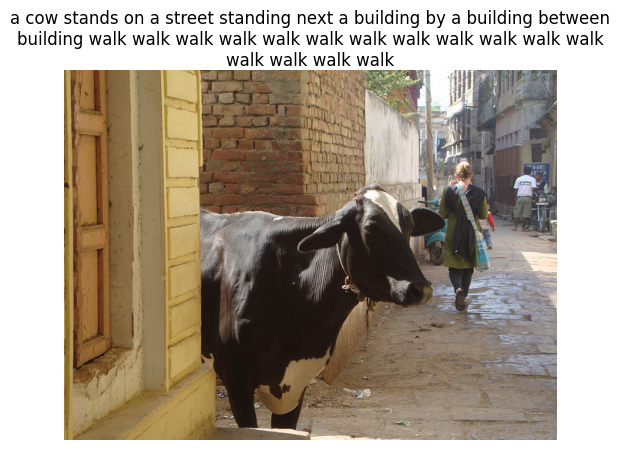

Image ID: 52516
Caption: a bride and groom pose for a bride and groom pose for a bride and groom for a horse and carriage on a city street


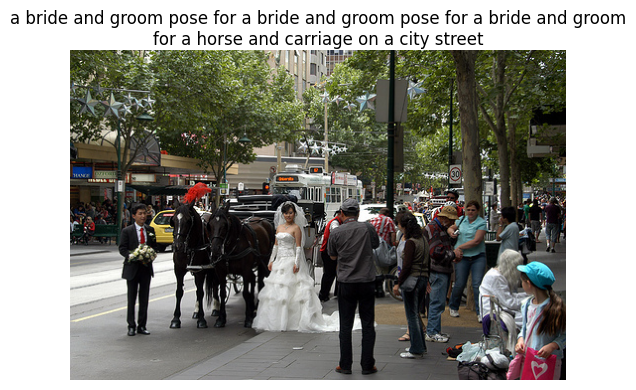

Image ID: 46371
Caption: a bearded man in the suit has on a hat hat hat green hat hat hat green hat green hat hat hat green hat hat hat


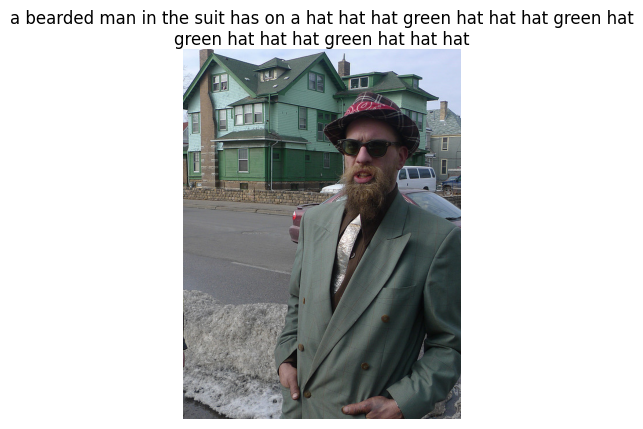

Image ID: 27522
Caption: a man flying through the air while riding a snowboard snowboard in mid air air air sky doing a snowboard in mid air air sky air sky air air air


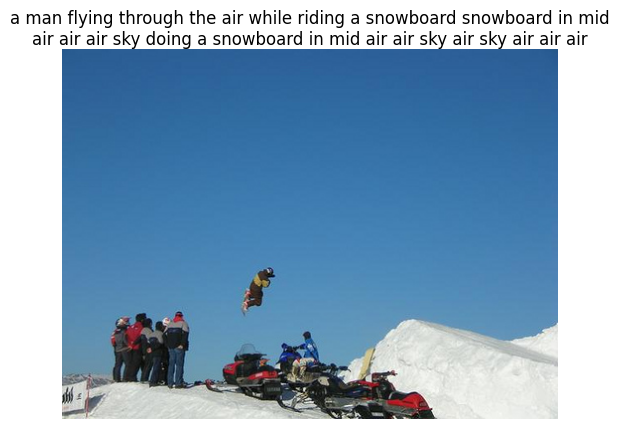

Image ID: 21020
Caption: a kitchen with microwave and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and pot and


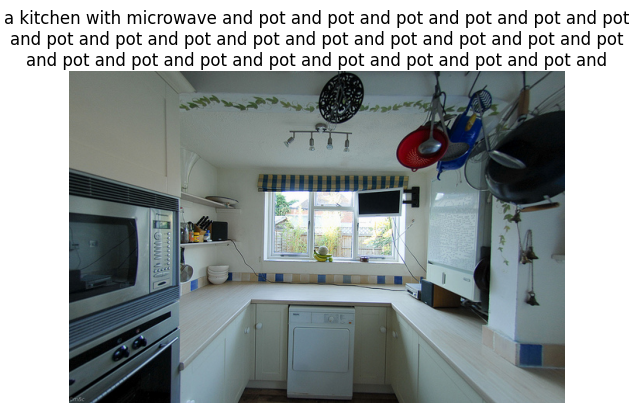

BLEU-1: 0.4615
BLEU-2: 0.4241
BLEU-3: 0.3846
BLEU-4: 0.3376


In [12]:
# ---- 1. Load captions ----
IMAGE_DIR = '/content/drive/MyDrive/train2014'
CAPTION_FILE = '/content/drive/MyDrive/annotations/captions_train2014.json'

with open(CAPTION_FILE) as f:
    data = json.load(f)

captions_dict = defaultdict(list)
for annot in data['annotations']:
    img_id = annot['image_id']
    caption = annot['caption']
    captions_dict[img_id].append(caption)

# ---- 2. Clean captions ----
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # removes punctuation, not letters
    text = re.sub(r'\s+', ' ', text)     # remove extra spaces
    return 'startseq ' + text.strip() + ' endseq'

for img_id in captions_dict:
    captions_dict[img_id] = [clean_text(cap) for cap in captions_dict[img_id]]

# ---- 3. Extract VGG16 features ----
base_model = VGG16(include_top=False, weights='imagenet')
vgg_model = Model(inputs=base_model.input, outputs=base_model.output)  # (7, 7, 512)

def extract_features(filename):
    img = load_img(filename, target_size=(224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    features = vgg_model.predict(img)  # (1, 7, 7, 512)
    features = np.reshape(features, (49, 512))  # (49, 512)
    return features

# ---- 4. Load and filter images ----
image_files = os.listdir(IMAGE_DIR)[:50]
features_dict = {}
image_ids = []

for img_file in tqdm(image_files):
    img_id = int(img_file.split('_')[-1].split('.')[0])
    if img_id in captions_dict:
        path = os.path.join(IMAGE_DIR, img_file)
        features_dict[img_id] = extract_features(path)
        image_ids.append(img_id)

# ---- 5. Tokenizer ----
all_captions = []
for caps in captions_dict.values():
    all_captions.extend(caps)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in all_captions)

# ---- 6. Create Sequences ----
def create_sequences(tokenizer, max_length, desc_list, photo_features, vocab_size):
    X1, X2, y = [], [], []
    for desc in desc_list:
        seq = tokenizer.texts_to_sequences([desc])[0]
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            X1.append(photo_features)
            X2.append(in_seq)
            y.append(out_seq)
    return np.array(X1), np.array(X2), np.array(y)

# ---- 7. Attention Mechanism ----
def define_model_with_attention(vocab_size, max_length):
    # Image features input: (49, 512)
    image_input = Input(shape=(49, 512))
    image_features_projected = Dense(256, activation='relu')(image_input) # Project to (batch, 49, 256)

    # Text input
    caption_input = Input(shape=(max_length,), name='caption_input')
    caption_embed = Embedding(vocab_size, 256, mask_zero=True)(caption_input)
    caption_lstm_out = LSTM(256, return_sequences=True)(caption_embed)

    # Attention
    attention = Dot(axes=[2, 2], name='attention_scores')([caption_lstm_out, image_features_projected])
    attention_weights = Activation('softmax', name='attention_weights')(attention)
    context = Dot(axes=[2, 1], name='context_vector')([attention_weights, image_features_projected])  # (batch, time, 512)

    # Combine context with LSTM output
    combined = Concatenate(axis=-1, name='combined_features')([context, caption_lstm_out])
    last_combined = combined[:, -1, :]
    #output = Dense(256, activation='relu')(combined)
    output = Dense(256, activation='relu', name='dense_output1')(last_combined)
    output = Dense(vocab_size, activation='softmax', name='output')(output) # (batch, vocab_size)

    model = Model(inputs=[image_input, caption_input], outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001))
    return model

model = define_model_with_attention(vocab_size, max_length)

# ---- 8. Train ----
X1_all, X2_all, y_all = [], [], []
for img_id in image_ids:
    photo = features_dict[img_id]
    desc_list = captions_dict[img_id]
    X1, X2, y = create_sequences(tokenizer, max_length, desc_list, photo, vocab_size)
    X1_all.extend(X1)
    X2_all.extend(X2)
    y_all.extend(y)

model.fit([np.array(X1_all), np.array(X2_all)], np.array(y_all), epochs=40, batch_size=64)


def generate_caption_beam_search(model, tokenizer, photo, max_length, beam_width=3):
    start = [tokenizer.word_index['startseq']]
    sequences = [[start, 0.0]]
    photo_input = photo.reshape((1, 49, 512))
    for _ in range(max_length):
        all_candidates = []
        for seq, score in sequences:
            padded = pad_sequences([seq], maxlen=max_length)
            preds = model.predict([photo_input, padded], verbose=0)[0]
            top_indices = np.argsort(preds)[-beam_width:]
            for idx in top_indices:
                word_prob = preds[idx]
                candidate_seq = seq + [idx]
                new_score = score - np.log(word_prob + 1e-10)
                all_candidates.append([candidate_seq, new_score])
        #ordered = sorted(all_candidates, key=lambda tup: tup[1])
        sequences = sorted(all_candidates, key=lambda tup: tup[1])[:beam_width]
    best_seq = sequences[0][0]
    caption = [tokenizer.index_word.get(idx, '') for idx in best_seq]
    return ' '.join([w for w in caption if w not in ['startseq', 'endseq', None]])

# ---- 9. DISPLAY FUNCTION ----
def show_image_with_caption(img_path, caption):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption, wrap=True)
    plt.show()


# ---- 10. TEST BEAM SEARCH ON A FEW IMAGES ----
sample_img_ids = image_ids[:5]  # pick first 5 images

for img_id in sample_img_ids:
    photo_feature = features_dict[img_id]
    beam_caption = generate_caption_beam_search(model, tokenizer, photo_feature, max_length, beam_width=3)
    # Remove startseq and endseq for clean caption
    beam_caption_clean = beam_caption
    # Compose file path
    img_filename = f'COCO_train2014_{img_id:012d}.jpg'
    img_path = os.path.join(IMAGE_DIR, img_filename)

    print(f"Image ID: {img_id}")
    print(f"Caption: {beam_caption_clean}")
    show_image_with_caption(img_path, beam_caption_clean)

# ---- 11. BLEU SCORE EVALUATION
def evaluate_model(model, captions_dict, features_dict, tokenizer, max_length, n_samples=100):
    smooth = SmoothingFunction().method4
    actual, predicted = [], []

    keys = list(features_dict.keys())[:n_samples]
    for key in keys:
        photo = features_dict[key]
        y_pred = generate_caption_beam_search(model, tokenizer, photo, max_length, beam_width=3)
        y_pred_clean = y_pred

        refs = [cap.split() for cap in captions_dict[key]]
        actual.append(refs)
        predicted.append(y_pred.split())

    bleu1 = np.mean([sentence_bleu(a, p, weights=(1.0, 0, 0, 0), smoothing_function=smooth) for a, p in zip(actual, predicted)])
    bleu2 = np.mean([sentence_bleu(a, p, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth) for a, p in zip(actual, predicted)])
    bleu3 = np.mean([sentence_bleu(a, p, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth) for a, p in zip(actual, predicted)])
    bleu4 = np.mean([sentence_bleu(a, p, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth) for a, p in zip(actual, predicted)])

    print(f'BLEU-1: {bleu1:.4f}')
    print(f'BLEU-2: {bleu2:.4f}')
    print(f'BLEU-3: {bleu3:.4f}')
    print(f'BLEU-4: {bleu4:.4f}')

# ---- 10. RUN EVALUATION ----
evaluate_model(model, captions_dict, features_dict, tokenizer, max_length, n_samples=100)